# PDHG for SIRF


In [9]:
import os
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import sirf.STIR as pet
from sirf.Utilities import examples_data_path
from tqdm import tqdm
import torch
from deepinv.models import DRUNet

msg_red = pet.MessageRedirector('info.txt', 'warnings.txt', 'errors.txt')

examples_data_path_PET = '/opt/SIRF-SuperBuild/INSTALL/share/SIRF-3.9/data/examples/PET'
data_path = os.path.join(examples_data_path_PET, 'thorax_single_slice')



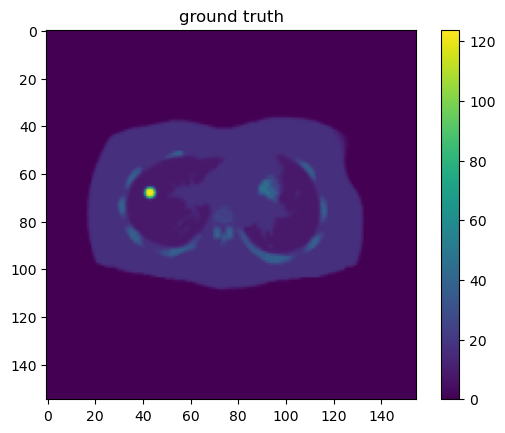

In [10]:

def make_cylindrical_fov(image):
    arr = image.as_array()
    nz, ny, nx = arr.shape
    yy, xx = np.ogrid[:ny, :nx]
    cy, cx = (ny - 1) / 2.0, (nx - 1) / 2.0
    radius = min(nx, ny) / 2.0
    mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2
    arr *= mask[None, :, :]
    image.fill(arr)
    return image
    
def build_problem():
    image = pet.ImageData(os.path.join(data_path, 'emission.hv')) * 2
    attn_image = pet.ImageData(os.path.join(data_path, 'attenuation.hv'))
    template = pet.AcquisitionData(os.path.join(data_path, 'template_sinogram.hs'))

    # acq_model_for_attn = pet.AcquisitionModelUsingRayTracingMatrix()
    # asm_attn = pet.AcquisitionSensitivityModel(attn_image, acq_model_for_attn)
    # asm_attn.set_up(template)
    # attn_factors = asm_attn.forward(template.get_uniform_copy(1))
    # asm_attn = pet.AcquisitionSensitivityModel(attn_factors)

    acq_model = pet.AcquisitionModelUsingRayTracingMatrix()
    acq_model.set_num_tangential_LORs(5)
    # acq_model.set_acquisition_sensitivity(asm_attn)
    acq_model.set_up(template, image)

    clean_data = acq_model.forward(image)
    acquired_data = clean_data.clone()
    acquired_data.fill(np.random.poisson(clean_data.as_array()).astype(np.float32))

    obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
    obj_fun.set_acquisition_model(acq_model)

    initial = image.get_uniform_copy(image.max() * 0.15)
    make_cylindrical_fov(initial)

    if hasattr(obj_fun, 'set_num_subsets'):
        obj_fun.set_num_subsets(1)
    if hasattr(obj_fun, 'set_up'):
        obj_fun.set_up(initial)

    return image, acquired_data, acq_model, obj_fun, initial
    
ground_truth, acquired_data, acq_model, obj_fun, x = build_problem()

plt.imshow(ground_truth.as_array()[0,:,:])
plt.colorbar()
plt.title('ground truth')
plt.show()


In [11]:
from cil.optimisation.algorithms import PDHG
from cil.optimisation.functions import KullbackLeibler, IndicatorBox, BlockFunction
from cil.optimisation.operators import BlockOperator

f = KullbackLeibler(b=acquired_data, eta=(acquired_data * 0 + 1e-5))
K = acq_model
normK = K.norm()

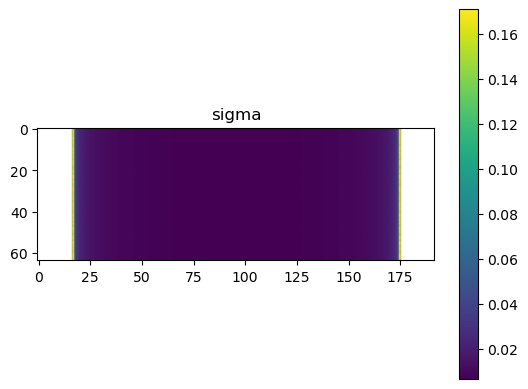

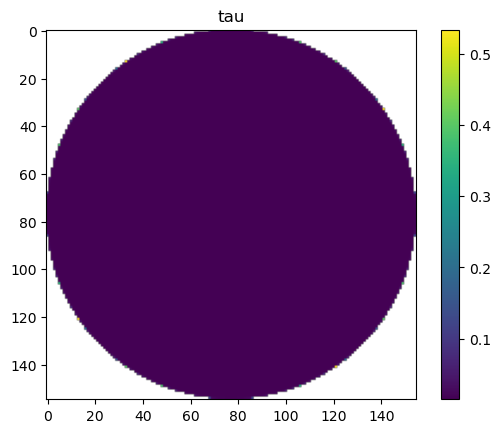

In [12]:
ones_data = acquired_data.clone().fill(1)
ones_image = ground_truth.clone().fill(1)

gamma = 1
sigma = gamma*ones_data/acq_model.get_linear_acquisition_model().forward(ones_image)
tau = 1/gamma*ones_image/acq_model.backward(ones_data)

plt.imshow(sigma.as_array()[0,0,:,:])
plt.colorbar()
plt.title('sigma')
plt.show()

plt.imshow(tau.as_array()[0,:,:])
plt.colorbar()
plt.title('tau')
plt.show()


In [ ]:

for gamma in [1e-4]:
    sigma = gamma*ones_data/acq_model.get_linear_acquisition_model().forward(ones_image)
    tau = 1/gamma*ones_image/acq_model.backward(ones_data)
    
    g = IndicatorBox(lower=0)
    
    def do_nothing(self):
        return 0.
    setattr(PDHG, 'update_objective', do_nothing)
    
    # Setup and run PDHG
    
    
    pdhg = PDHG(f=f, g=g, operator=K, sigma=sigma, tau=tau, 
                update_objective_interval = 4, 
                check_convergence=False)
    
    pdhg.run(100)
    
    pdhg_recon = pdhg.get_output()   

    pdhg_recon.shape

    plt.imshow(pdhg_recon.as_array()[0,:,:])
    plt.colorbar()
    plt.title(gamma)
    plt.show()



  0%|          | 0/100 [00:00<?, ?it/s]

applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...